# 02 — A two-line latency model has a model-dependent breakpoint.

The additive selection objective assigns a cost $T[|C|]$ to each contiguous
chunk. Replacing that table by a structured function can simplify the
optimization, but the boundary in the function need not coincide with a
physical saturation point. The saved latency profile lets us distinguish
a throughput threshold, a minimum cost per byte, and two fitted boundaries.

In [90]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from IPython.display import Markdown, Image, display
import importlib

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
import chunk_latency
chunk_latency = importlib.reload(chunk_latency)
SEED, TRAIN_BLOCKS, BOOTSTRAP_REPEATS = 0, 4, 1000
RERUN_MEASUREMENTS = False
DATA_DIR = ROOT / "runs/02_chunk_latency"
MEASUREMENT_CONFIG = dict(chunk_latency.DEFAULT_CONFIG, seed=SEED)
RUN, raw, estimates, hardware = chunk_latency.acquire(
    DATA_DIR, rerun=RERUN_MEASUREMENTS,
    submodule=ROOT.parents[1] / "preliminary_research/vlm-flash",
    config=MEASUREMENT_CONFIG)
before = chunk_latency.input_hashes(RUN)
OUT = RUN / "breakpoint_comparison"
OUT.mkdir(parents=True, exist_ok=True)
curve, samples = chunk_latency.split_curve(estimates, TRAIN_BLOCKS)
x = curve.size_kib.to_numpy()
T, T_train, T_test = (curve[c].to_numpy() for c in ("median_ms", "train_ms", "holdout_ms"))
parameters, search = chunk_latency.train_models(x, T_train)
fits, predictions = chunk_latency.compare_models(x, T_test, parameters)
order = ["Ts@240", "Ts@256", "Ts@230", "Ts learned", "Hinge", "Affine"]
names = {"Ts@240": "Two-line (240 KiB)", "Ts@256": "Two-line (256 KiB)",
         "Ts@230": "Two-line (230 KiB)", "Ts learned": "Two-line (free breakpoint)",
         "Hinge": "Hinge (free breakpoint)", "Affine": "Affine"}
stats = fits.set_index("model")
s99, B_train, B_smooth, peak = chunk_latency.throughput_threshold(x, T_train)
s_all, B_all, B_all_smooth, _ = chunk_latency.throughput_threshold(x, T)
s_star = parameters["Ts learned"]["s_kib"]
h_star = parameters["Hinge"]["s_kib"]
rho = T / x
x_rho = float(x[rho.argmin()])
tail = x >= s99
below = int(np.sum(B_smooth[tail] < .99 * peak))
n_tail = int(tail.sum())
test_ratio = T_test[tail] / x[tail]
tail_cv = 100 * np.std(test_ratio, ddof=1) / np.mean(test_ratio)
tail_drift = 100 * (test_ratio[-1] / test_ratio[0] - 1)
ts_search = search[search.kind == "Ts"]
band = ts_search[ts_search.train_rmse_us <= 1.01 * ts_search.train_rmse_us.min()]
a_h, b_h, d_h = parameters["Hinge"]["coefficients"]
tail_intercept_us = 1000 * (a_h - d_h * h_star)

def prose(text):
    display(Markdown(text))

def figure(name, caption):
    fig = plt.gcf()
    fig.tight_layout()
    fig.savefig(OUT / (name + ".png"), dpi=150, bbox_inches="tight")
    fig.savefig(OUT / (name + ".svg"), bbox_inches="tight",
                metadata={"Date": None})
    plt.close(fig)
    display(Image(filename=str(OUT / (name + ".png"))))
    prose(caption)

plt.rcParams.update({"font.size": 10, "svg.hashsalt": "chunk-latency-report"})

In [91]:
prose(
    f"For this profile, the minimum cost per byte occurs at **{x_rho:g} KiB**. "
    f"A continuous two-line model anchored at 240 KiB has **{stats.loc['Ts@240', 'holdout_mape_pct']:.2f}%** "
    f"holdout MAPE. Optimizing the boundary within the same family selects **{s_star:g} KiB** "
    f"and gives **{stats.loc['Ts learned', 'holdout_mape_pct']:.2f}%** MAPE. "
    "The difference concerns how a model approximates the table; it does not change the measured read times.")

For this profile, the minimum cost per byte occurs at **240 KiB**. A continuous two-line model anchored at 240 KiB has **3.80%** holdout MAPE. Optimizing the boundary within the same family selects **211 KiB** and gives **3.33%** MAPE. The difference concerns how a model approximates the table; it does not change the measured read times.

## The minimum cost per byte is not a sustained throughput plateau.

Let $x>0$ denote **logical chunk length in KiB**, and let $\widehat B_b(x)$ be
the throughput estimate in acquisition block $b$. Define

$$\widehat T_b(x)=\frac{1000x}{1024\widehat B_b(x)}\quad\text{ms/chunk},
\qquad \rho(x)=\frac{T(x)}x,
\qquad B(x)=\frac{1000}{1024\rho(x)}.$$

This is an amortized cost derived from several reads, not the service time
of one isolated read. Here $T(x)$ is the median of the block estimates.
Consequently $\arg\min_x\rho(x)=\arg\max_x B(x)$; this identity says
nothing about whether throughput remains at its maximum for larger chunks.

The alternative first-crossing rule smooths the training throughput with
a three-point median $\widetilde B$ and defines

$$s_{99}=\min\{x\in\mathcal G:\widetilde B(x)\ge0.99\max_{u\in\mathcal G}\widetilde B(u)\}.$$

In [92]:
rho = T / x
x_rho = float(x[np.argmin(rho)])
s99, B_train, B_smooth, peak = chunk_latency.throughput_threshold(x, T_train)

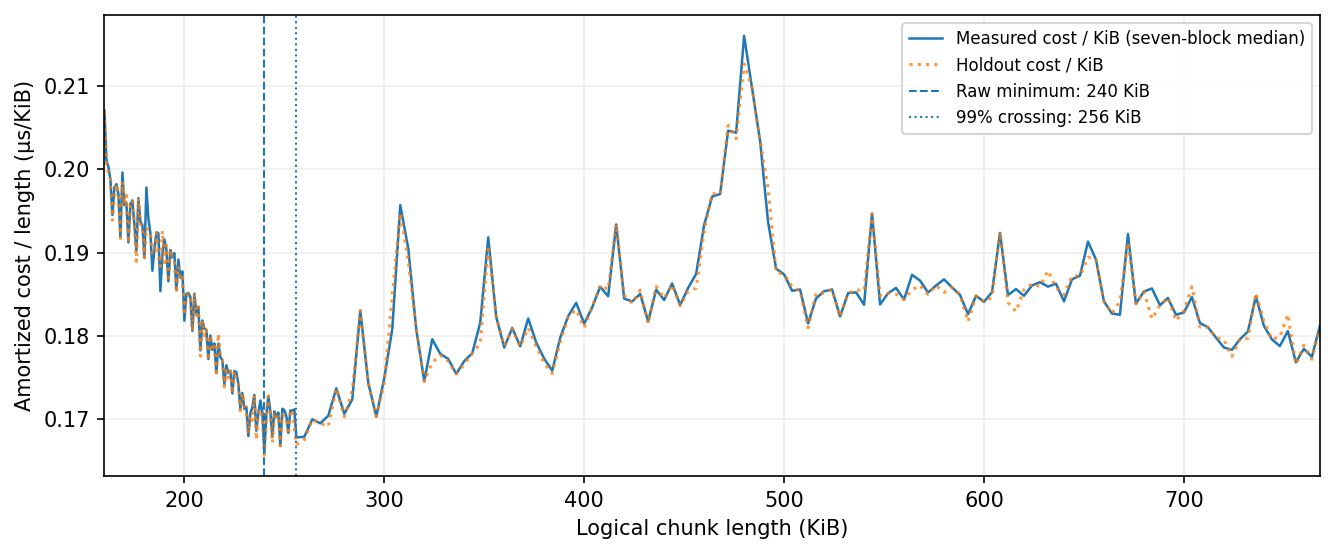

**Figure 1.** The measured minimum is **0.1660 µs/KiB at 240 KiB**. Only sizes at or above 160 KiB are shown here so that variation around the minimum remains visible.

The smoothed training curve first crosses 99% at **256 KiB**, but **125/129** measured sizes at or beyond that crossing fall below the same threshold. On the holdout curve, $T/x$ over that interval has a **4.03%** coefficient of variation and changes by **+8.36%** between its endpoints. A first crossing and a durable plateau are therefore different claims.

In [93]:
plt.figure(figsize=(9, 3.8))
zoom = x >= 160
plt.plot(x[zoom], 1000 * rho[zoom], linewidth=1.2, label="Measured cost / KiB (seven-block median)")
plt.plot(x[zoom], 1000 * T_test[zoom] / x[zoom], ":", alpha=.8, label="Holdout cost / KiB")
plt.axvline(x_rho, ls="--", lw=1, label=f"Raw minimum: {x_rho:g} KiB")
plt.axvline(s99, ls=":", lw=1, label=f"99% crossing: {s99:g} KiB")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Amortized cost / length (µs/KiB)")
plt.xlim(160, x[-1])
plt.legend(fontsize=8, loc="upper right")
figure("efficiency_and_breakpoints",
    f"**Figure 1.** The measured minimum is **{1000 * rho.min():.4f} µs/KiB at {x_rho:g} KiB**. "
    "Only sizes at or above 160 KiB are shown here so that variation around the minimum remains visible.")
prose(
    f"The smoothed training curve first crosses 99% at **{s99:g} KiB**, "
    f"but **{below}/{n_tail}** measured sizes at or beyond that crossing fall below the same threshold. "
    f"On the holdout curve, $T/x$ over that interval has a **{tail_cv:.2f}%** coefficient of variation "
    f"and changes by **{tail_drift:+.2f}%** between its endpoints. "
    "A first crossing and a durable plateau are therefore different claims.")

## A boundary fixed at 240 KiB gives a useful two-line approximation.

Consider the continuous family, for $x>0$,

$$\boxed{T_s(x)=c_1x+\delta\max(s,x)
  =\begin{cases}\delta s+c_1x,&x\le s,\\
                  (c_1+\delta)x,&x\ge s,
    \end{cases}\qquad c_1,\delta\ge0.}$$

Continuity ties the short-chunk intercept to the boundary: $a=\delta s$.
The long-chunk line passes through the origin, so $T_s(x)/x=c_1+\delta$
is exactly constant after $s$. This is a restriction on the model, not
an observation that the device has an exactly constant tail.

**Every model below has fitted coefficients.** “Fixed” and “free” describe
only the treatment of the breakpoint. At each of 240, 256, and 230 KiB,
the coefficients are fitted again by nonnegative least squares.

In [94]:
X_s = lambda s: np.column_stack((x, np.maximum(s, x)))
theta = lambda s: nnls(X_s(s), T_train)[0]
T_240 = X_s(240) @ theta(240)

For the 240 KiB boundary, the fitted function is approximately

$$T_{240}(x)=\begin{cases}0.011369+0.000136107x,&x\le240,\\0.000183478x,&x\ge240,\end{cases}\quad\text{ms}.$$

Coefficients are rounded here; the calculations retain full precision.

| Model | Boundary | KiB | Holdout RMSE (µs) | Holdout MAPE |
|:--|:--|--:|--:|--:|
| Two-line | Fixed | 240 | 2.323 | 3.80% |
| Two-line | Fixed | 256 | 2.456 | 4.27% |
| Two-line | Fixed | 230 | 2.265 | 3.59% |
| Two-line | Free | 211 | 2.218 | 3.33% |
| Hinge | Free | 230 | 2.094 | 2.92% |
| Affine | — | — | 3.816 | 10.00% |

Replacing the 256 KiB anchor by 240 KiB reduces holdout RMSE by **5.39%** in this comparison. That is a reduction in prediction error, not an SSD speedup.

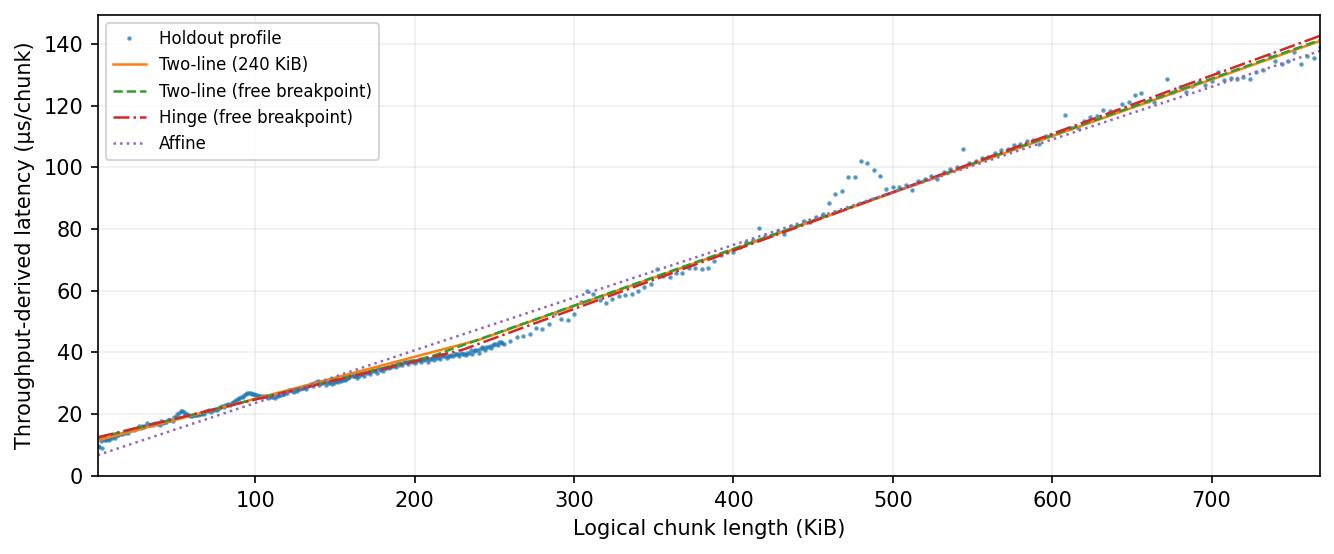

**Figure 2.** Models fitted on the first four blocks, evaluated against the last three. The structured curves are close on this scale; residuals below reveal their differences. The full comparison table includes the two additional fixed boundaries.

In [95]:
c1, delta = theta(240)
prose(r"For the 240 KiB boundary, the fitted function is approximately" + "\n\n" +
    rf"$$T_{{240}}(x)=\begin{{cases}}{240 * delta:.6f}+{c1:.9f}x,&x\le240,\\" +
    rf"{c1 + delta:.9f}x,&x\ge240,\end{{cases}}\quad\text{{ms}}.$$" +
    "\n\nCoefficients are rounded here; the calculations retain full precision.")
lines = ["| Model | Boundary | KiB | Holdout RMSE (µs) | Holdout MAPE |",
         "|:--|:--|--:|--:|--:|"]
for key in order:
    row = stats.loc[key]
    family = "Two-line" if row.kind == "Ts" else "Hinge" if row.kind == "Hinge" else "Affine"
    treatment = "Free" if key in ("Ts learned", "Hinge") else "—" if key == "Affine" else "Fixed"
    location = "—" if pd.isna(row.s_kib) else f"{row.s_kib:g}"
    lines.append(f"| {family} | {treatment} | {location} | {row.holdout_rmse_us:.3f} | {row.holdout_mape_pct:.2f}% |")
prose("\n".join(lines))
gain = 100 * (1 - stats.loc["Ts@240", "holdout_rmse_us"] / stats.loc["Ts@256", "holdout_rmse_us"])
prose(f"Replacing the 256 KiB anchor by 240 KiB reduces holdout RMSE by **{gain:.2f}%** "
    "in this comparison. That is a reduction in prediction error, not an SSD speedup.")
plt.figure(figsize=(9, 3.8))
plt.plot(x, T_test * 1000, ".", ms=2.5, alpha=.6, label="Holdout profile")
for key, style in [("Ts@240", "-"), ("Ts learned", "--"), ("Hinge", "-."), ("Affine", ":")]:
    plt.plot(x, predictions[key] * 1000, style, lw=1.2, label=names[key])
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Throughput-derived latency (µs/chunk)")
plt.xlim(x[0], x[-1])
plt.legend(fontsize=8)
figure("latency_models_holdout",
    "**Figure 2.** Models fitted on the first four blocks, evaluated against the last three. "
    "The structured curves are close on this scale; residuals below reveal their differences. "
    "The full comparison table includes the two additional fixed boundaries.")

## Fitting the two-line boundary is not the same as fitting a free hinge.

Let $\mathcal G^\circ$ be the interior measured grid, excluding the first
and last three sizes. For the constrained family, the fitted boundary is

$$\boxed{s_\star\in\arg\min_{s\in\mathcal G^\circ}
\min_{c_1,\delta\ge0}\frac1{|\mathcal G|}
\sum_{x\in\mathcal G}\big[T_{\rm train}(x)-c_1x-\delta\max(s,x)\big]^2.}$$

By contrast, a continuous hinge has the form

$$T_H(x)=a+bx+d(x-h)_+.$$

It also chooses its boundary from training error, but its tail is
$(a-dh)+(b+d)x$: unlike $T_s$, its long-chunk intercept need not vanish.
A free-boundary two-line fit has three parameters; a free hinge has four.
The two optimizations consequently need not place their bends together.

In [96]:
G = x[3:-3]
loss = lambda s: np.mean((T_train - X_s(s) @ theta(s)) ** 2)
s_star = float(min(G, key=loss))

The constrained family selects **$s_\star=211$ KiB**; the free hinge selects **$h_\star=230$ KiB**. The hinge's fitted long-chunk intercept is **-2.645 µs**, whereas the constrained family's is exactly zero. Fixing $T_s$ at the hinge location does not turn it into the hinge model.

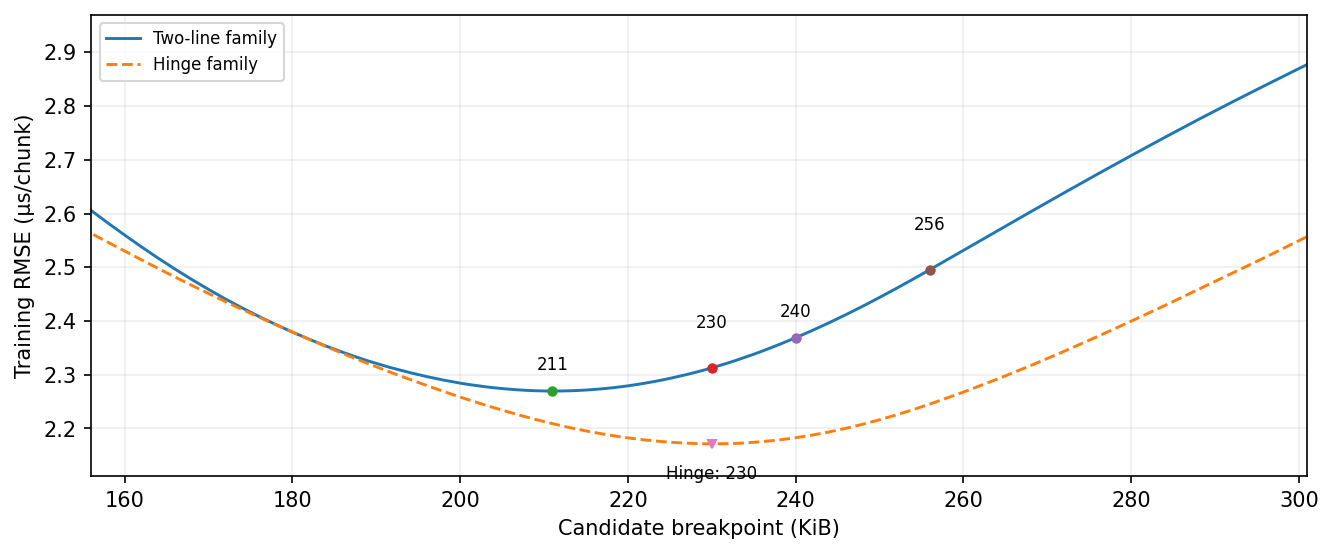

**Figure 3.** Each point on a curve refits that family's coefficients at the candidate boundary. Circles show the four nominated boundaries in the two-line family; the triangle marks the hinge minimum. The view is enlarged around them. Neither search uses holdout error.

The two-line minimum is not sharply isolated: the measured candidates within **1% of the minimum training RMSE** span **198–224 KiB**. This is an objective-sensitivity set, not a confidence interval. The objective weights measured sizes equally, so its optimum also depends on the sampling grid. Thus 211 KiB is a fitted model parameter, not a newly established optimal physical read size.

In [97]:
prose(
    rf"The constrained family selects **$s_\star={s_star:g}$ KiB**; the free hinge selects "
    rf"**$h_\star={h_star:g}$ KiB**. The hinge's fitted long-chunk intercept is "
    f"**{tail_intercept_us:+.3f} µs**, whereas the constrained family's is exactly zero. "
    "Fixing $T_s$ at the hinge location does not turn it into the hinge model.")
plt.figure(figsize=(9, 3.8))
for kind, label, style in [("Ts", "Two-line family", "-"), ("Hinge", "Hinge family", "--")]:
    group = search[search.kind == kind]
    plt.plot(group.s_kib, group.train_rmse_us, style, lw=1.4, label=label)
points = [s_star, h_star, 240., 256.]
for i, s0 in enumerate(sorted(set(points))):
    r0 = 1000 * np.sqrt(loss(s0))
    plt.plot(s0, r0, "o", ms=4)
    plt.annotate(f"{s0:g}", (s0, r0), xytext=(0, 10 + 9 * (i % 2)),
                 textcoords="offset points", ha="center", fontsize=8)
left, right = max(G[0], min(points) - 55), min(G[-1], max(points) + 45)
local = search[search.s_kib.between(left, right)]
plt.xlim(left, right)
plt.ylim(local.train_rmse_us.min() - .06, local.train_rmse_us.max() + .10)
plt.xlabel("Candidate breakpoint (KiB)")
plt.ylabel("Training RMSE (µs/chunk)")
hinge_min = 1000 * np.sqrt(parameters["Hinge"]["train_mse_ms2"])
plt.plot(h_star, hinge_min, "v", ms=4)
plt.annotate(f"Hinge: {h_star:g}", (h_star, hinge_min), xytext=(0, -17),
             textcoords="offset points", ha="center", fontsize=8)
plt.legend(fontsize=8)
figure("breakpoint_training_objective",
    "**Figure 3.** Each point on a curve refits that family's coefficients at the candidate boundary. "
    "Circles show the four nominated boundaries in the two-line family; the triangle marks the hinge minimum. The view is enlarged around them. "
    "Neither search uses holdout error.")
prose(
    f"The two-line minimum is not sharply isolated: the measured candidates within "
    "**1% of the minimum training RMSE** span "
    f"**{band.s_kib.min():g}–{band.s_kib.max():g} KiB**. This is an objective-sensitivity set, not a confidence interval. "
    "The objective weights measured sizes equally, so its optimum also depends on the sampling grid. "
    f"Thus {s_star:g} KiB is a fitted model parameter, not a newly established optimal physical read size.")

## The approximation does not make the residual structure disappear.

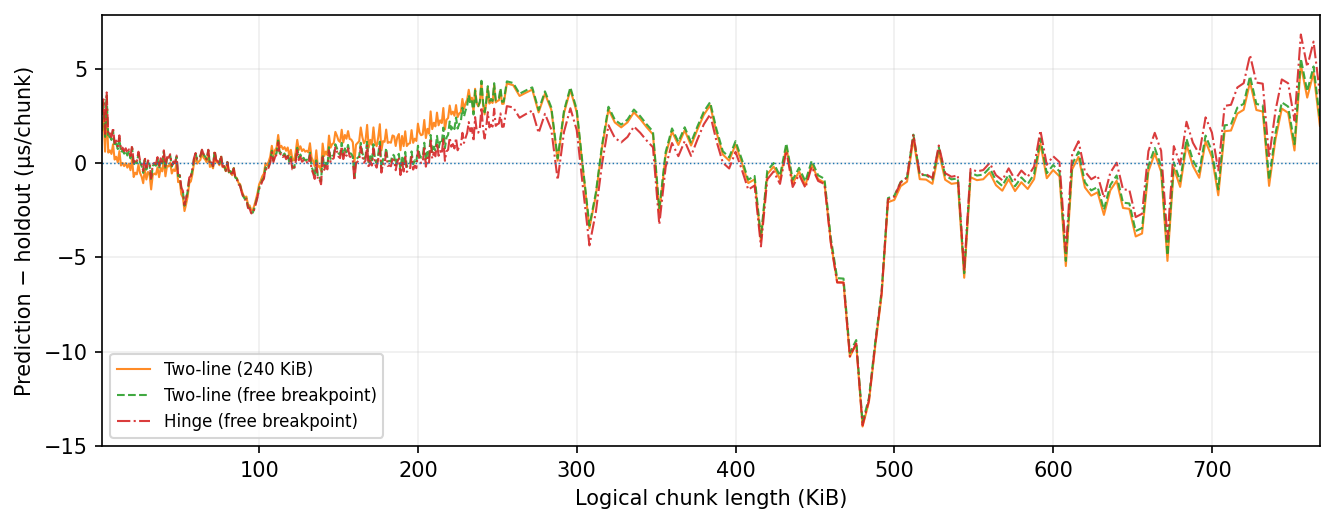

**Figure 4.** Moving the boundary reduces aggregate error without removing the local departures shared by the structured fits. Negative residuals mean that the model underestimates latency.

The free-boundary two-line fit has holdout RMSE **2.218 µs**, compared with **2.094 µs** for the hinge. The visible departure near 480 KiB is not explained away by choosing a different boundary. Low average error supports a useful engineering approximation; it does not establish an exact two-line law.

In [98]:
plt.figure(figsize=(9, 3.6))
plt.plot([], [], ".", label="_profile")  # Keep the same model cycle as Figure 2.
for key, style in [("Ts@240", "-"), ("Ts learned", "--"), ("Hinge", "-.")]:
    plt.plot(x, 1000 * (predictions[key] - T_test), style, lw=1, alpha=.9, label=names[key])
plt.axhline(0, ls=":", lw=.7)
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Prediction − holdout (µs/chunk)")
plt.xlim(x[0], x[-1])
plt.legend(fontsize=8, loc="lower left")
figure("holdout_residuals",
    "**Figure 4.** Moving the boundary reduces aggregate error without removing the local departures "
    "shared by the structured fits. Negative residuals mean that the model underestimates latency.")
r_free, r_hinge = (stats.loc[k, "holdout_rmse_us"] for k in ("Ts learned", "Hinge"))
prose(
    f"The free-boundary two-line fit has holdout RMSE **{r_free:.3f} µs**, compared with "
    f"**{r_hinge:.3f} µs** for the hinge. The visible departure near 480 KiB is not explained "
    "away by choosing a different boundary. Low average error supports a useful engineering approximation; "
    "it does not establish an exact two-line law.")

The four lengths therefore answer different questions. The throughput crossing
is a threshold on a smoothed curve; the raw-efficiency minimum selects a point
on the measured curve; the hinge and the constrained two-line model minimize
different approximation errors. For this saved profile, they are

In [99]:
prose(rf"$$\boxed{{s_{{99}}={s99:g},\quad x_\rho={x_rho:g},\quad h_\star={h_star:g},\quad s_\star={s_star:g}\quad\mathrm{{KiB}}.}}$$")

$$\boxed{s_{99}=256,\quad x_\rho=240,\quad h_\star=230,\quad s_\star=211\quad\mathrm{KiB}.}$$

For selection algorithms, the observed cost-per-byte minimum remains an
interpretable reference. The free-boundary $T_s$ answers a
different question: how closely this restricted family can reproduce $T$.
Neither fit alone proves that a chunking policy improves the original
lookup-table objective. Guarantees derived for $T_s$ remain conditional on
that model, and predictions beyond the measured range require further data.

### Measurement and comparison scope

The saved native six-worker profile contains seven randomized blocks and 384
logical sizes: 1–256 KiB in 1 KiB steps and 260–768 KiB in 4 KiB steps.
Medians of the first four blocks determine coefficients and free boundaries;
medians of the last three determine holdout errors. Each acquisition used
a chunk-count sweep, three warmups and ten timings per count. No native
measurements are repeated to produce this report.

The fixed candidates were nominated after earlier inspection of this same
run; in particular, 240 KiB is the **all-seven-block** efficiency minimum.
The comparison is therefore retrospective within one run, not a fresh
confirmatory holdout experiment. The two free-boundary searches themselves
use training data only. The derived latency and its units are specific to
this reader and measurement procedure, not a universal SSD service-time law.

[Mathematical context](../../preliminary_research/idea.md) ·
[Saved measurements](runs/02_chunk_latency/)